In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ad_afqmc import (
    lattices,
)

In [3]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif'] = cmfont.get_name()
plt.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())

In [4]:
colors

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [5]:
def get_spin_charge_corr_from_density_corr(density_corr):
    """
    density_corr[I, J] = <n_{i, sigma} n_{j, tau}> in spin-orbital basis:
        - density_corr[:n_sites, :n_sites] = <n_{i, up} n_{j, up}>
        - density_corr[n_sites:, n_sites:] = <n_{i, down} n_{j, down}>
        = density_corr[:n_sites, n_sites:] = <n_{i, up} n_{j, down}>
        = density_corr[n_sites:, :n_sites] = <n_{i, up} n_{j, up}>
        
    Returns the charge and Sz connected correlators on each site.
    """
    density_corr = np.asarray(density_corr)
    n_sites = density_corr.shape[0] // 2
    
    nn_aa = density_corr[:n_sites, :n_sites]
    nn_ab = density_corr[:n_sites, n_sites:]
    nn_ba = density_corr[n_sites:, :n_sites]
    nn_bb = density_corr[n_sites:, n_sites:]

    # One-body densities from diagonals (since n^2 = n).
    n_a = np.diag(nn_aa).real
    n_b = np.diag(nn_bb).real
    n = n_a + n_b
    sz = 0.5 * (n_a - n_b)

    # Total density-density correlation function, <n_i n_j>.
    nn_site = nn_aa + nn_ab + nn_ba + nn_bb

    # Connected charge correlator, <n_i n_j> - <n_i><n_j>.
    charge_corr = nn_site - np.outer(n, n)

    # Total Sz-Sz correlation function, <Sz_i Sz_j>.
    szsz = 0.25 * (nn_aa - nn_ab - nn_ba + nn_bb)
    spin_corr = szsz - np.outer(sz, sz)

    return charge_corr, spin_corr, n, sz

def get_structure_factor_from_corr(corr, coords, q_points):
    """
    corr: (n_sites, n_sites) connected correlator (spin or charge)
    coords: (n_sites, 2) real-space positions
    q_points: (Nq, 2) list of q-vectors
    returns S(q) of shape (Nq,)
    """
    corr = np.asarray(corr)
    coords = np.asarray(coords)
    q_points = np.asarray(q_points)
    n_sites = coords.shape[0]
    sf = np.zeros(q_points.shape[0], dtype=float)

    for iq, q in enumerate(q_points):
        phase = np.exp(1j * (coords @ q))  # (n_sites, )
        # S(q) = 1/N \sum_{ij} e^{i*q*(r_i - r_j)} C_{ij}
        # S(q) = v^† C v / N with v_i = e^{i*q*r_i}
        sf[iq] = np.real(np.einsum("i,ij,j->", np.conj(phase), corr, phase)) / n_sites

    return sf

def bootstrap_ssf_linecut(density_corr, density_corr_err, coords, symm_kpts, n_boot=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    qs, kdist, labels = get_kpath(symm_kpts, n_per_seg=80)
    ssf_samples = np.empty((n_boot, len(kdist)))

    for ib in range(n_boot):
        noise = rng.normal(scale=np.abs(density_corr_err))
        noise = 0.5 * (noise + noise.T)
        nn_sample = density_corr + noise
        _, spin_corr_sample, _, _ = get_spin_charge_corr_from_density_corr(nn_sample)
        ssf_samples[ib] = get_structure_factor_from_corr(spin_corr_sample, coords, qs)

    ssf_mean = ssf_samples.mean(axis=0)
    ssf_std = ssf_samples.std(axis=0)

    return kdist, labels, ssf_mean, ssf_std

def plot_sf_contour(corr, coords, B, n_min=-0.5, n_max=0.5, n_k1=81, n_k2=81, fig=None, ax=None):
    n1 = np.linspace(n_min, n_max, n_k1)
    n2 = np.linspace(n_min, n_max, n_k2)
    n_arr = cartesian_prod([n1, n2])
    q_points = n_arr @ B.T
    sf = get_structure_factor_from_corr(corr, coords, q_points)

    if fig is None or ax is None: fig, ax = plt.subplots(figsize=(6, 6))

    x = q_points[:, 0].reshape(n_k1, n_k2)
    y = q_points[:, 1].reshape(n_k1, n_k2)
    z = sf.reshape(n_k1, n_k2)
    cf = ax.contourf(x, y, z, levels=40)
    
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r"$S(\mathbf{q})$")  # or N(q) for charge
    ax.set_xlabel(r"$q_x$")
    ax.set_ylabel(r"$q_y$")
    ax.set_aspect("equal")
    return fig, ax
        
def plot_sf_line_cut(corr, coords, symm_kpts, what="S", fig=None, ax=None, figsize=(6, 4), **kwargs):
    qs, kdist, labels = get_kpath(symm_kpts, n_per_seg=80)
    sf_line = get_structure_factor_from_corr(corr, coords, qs)

    if fig is None or ax is None: fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.plot(kdist, sf_line, "-", **kwargs)
    ax.set_ylabel(rf"${what}(\mathbf{{q}})$")
    ax.grid()

    # Put ticks at the high-symmetry points
    tick_positions = []
    tick_labels = []
    for idx, lab in zip(
        [0, len(kdist) // 3, 2 * len(kdist) // 3, len(kdist) - 1],  # rough positions
        labels,
    ):
        tick_positions.append(kdist[idx])
        tick_labels.append(lab)
        
    ax.set_xticks(tick_positions, tick_labels)
    return fig, ax

def get_sf_bz(corr, coords, B, n_pts=401):
    """
    corr   : (N,N) connected correlator (spin or charge)
    coords : (N,2) real-space coordinates from get_site_coordinate
    n_pts  : grid resolution in (k1,k2)
    """
    corr = np.asarray(corr)
    coords = np.asarray(coords)

    # grid in reduced coordinates (k1, k2)
    kmin, kmax = -4.0 / 3.0, 4.0 / 3.0
    k1 = np.linspace(kmin, kmax, n_pts)
    k2 = np.linspace(kmin, kmax, n_pts)
    K1, K2 = np.meshgrid(k1, k2, indexing="ij")

    # map to Cartesian k = k1 b1 + k2 b2
    b1, b2 = B.T
    KX = K1 * b1[0] + K2 * b2[0]
    KY = K1 * b1[1] + K2 * b2[1]

    # flatten q-points and evaluate structure factor
    q_points = np.stack([KX.ravel(), KY.ravel()], axis=1)
    sf_flat = get_structure_factor_from_corr(corr, coords, q_points)
    sf = sf_flat.reshape(n_pts, n_pts)

    # BZ.
    bz_corners = get_bz_corners(B)

    return sf, KX, KY, bz_corners

def plot_sf_bz(
    sf, KX, KY, B, bz_corners, symm_kpts, fig=None, ax=None, figsize=(6, 4), 
    ax_labels=True, ax_ticks=True, cb_label=True, fontsize=14,
    kpts_label_shifts=None
):
    if (fig is None) or (ax is None):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    
    cf = ax.contourf(KX, KY, sf, levels=51)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    if cb_label: label = rf"$S(\mathbf{{q}})$"
    else: label = ""
    cbar = fig.colorbar(cf, cax=cax, label=label)
    cbar.locator = mticker.MaxNLocator(5)   # ~5 ticks total
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=fontsize)
    
    # BZ outline
    bz_closed = np.vstack([bz_corners, bz_corners[0]])
    ax.plot(bz_closed[:, 0], bz_closed[:, 1], lw=1.6, color="w")

    # Γ, K, M.
    G, K, M = symm_kpts
    
    if kpts_label_shifts is None:
        kpts_label_shifts = []

        for ik in range(symm_kpts.shape[0]):
            if i == 0: 
                shift_x = -0.15
                shift_y = -0.7
        
            else:
                shift_x = -0.7
                shift_y = -0.15
            
            kpts_label_shifts.append([shift_x, shift_y])

        kpts_label_shifts = np.array(kpts_label_shifts)
            
    for ik, (label, k) in enumerate([(r"$\Gamma$", G), (r"$K$", K), (r"$M$", M)]):
        shift_x, shift_y = kpts_label_shifts[ik]
        ax.scatter(*k, marker="o", edgecolor='w', zorder=10)
        ax.text(k[0] + shift_x, k[1] + shift_y, label, color="w", fontsize=fontsize)
    
    pad = 0.15 * np.linalg.norm(B[:, 0])
    ax.set_xlim(bz_corners[:, 0].min() - pad, bz_corners[:, 0].max() + pad)
    ax.set_ylim(bz_corners[:, 1].min() - pad, bz_corners[:, 1].max() + pad)

    if ax_labels:
        ax.set_xlabel(r"$q_x$")
        ax.set_ylabel(r"$q_y$")

    if not ax_ticks:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(which="both", bottom=False, left=False,
                       labelbottom=False, labelleft=False)
        
    ax.set_aspect("equal")

    return fig, ax

In [6]:
def cartesian_prod(arrays, out=None):
    """
    Generate a cartesian product of input arrays.
    http://stackoverflow.com/questions/1208118/using-numpy-to-build-an-array-of-all-combinations-of-two-arrays

    Args:
        arrays : list of array-like
            1-D arrays to form the cartesian product of.

        out : ndarray
            Array to place the cartesian product in.

    Returns:
        out : numpy.ndarray
            2-D array of shape (M, len(arrays)) containing cartesian products
            formed of input arrays.

    Examples:

    >>> cartesian_prod(([1, 2, 3], [4, 5], [6, 7]))
    array([[1, 4, 6],
           [1, 4, 7],
           [1, 5, 6],
           [1, 5, 7],
           [2, 4, 6],
           [2, 4, 7],
           [2, 5, 6],
           [2, 5, 7],
           [3, 4, 6],
           [3, 4, 7],
           [3, 5, 6],
           [3, 5, 7]])

    """
    arrays = [np.asarray(x) for x in arrays]
    dtype = np.result_type(*arrays)
    nd = len(arrays)
    dims = [nd] + [len(x) for x in arrays]
    out = np.ndarray(dims, dtype, buffer=out)

    shape = [-1] + [1] * nd
    for i, arr in enumerate(arrays): out[i] = arr.reshape(shape[:nd-i])
    return out.reshape(nd, -1).T
    

def get_direct_recip_vecs(nrot=0):
    theta = np.pi / 3.0
    a1 = [np.cos(nrot*theta), np.sin(nrot*theta)]
    a2 = np.array([np.cos((nrot+1)*theta), np.sin((nrot+1)*theta)])
    A = np.stack([a1, a2], axis=1)  # columns = a1, a2
    B = 2 * np.pi * np.linalg.inv(A).T  # columns = b1, b2
    return A, B

def get_symm_kpts(B):
    G = np.array([0.0, 0.0])
    K = 2./3. * B[:, 0] + 1./3. * B[:, 1]
    M = 0.5 * np.sum(B, axis=1)
    symm_kpts = np.array([G, K, M])
    return symm_kpts

def get_kpath(symm_kpts, n_per_seg=80):
    G, K, M = symm_kpts
    path = [G, K, M, G]
    labels = [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$"]
    qs = []
    kdist = [0.0]

    for p0, p1 in zip(path[:-1], path[1:]):
        seg = np.linspace(0.0, 1.0, n_per_seg, endpoint=False)
        for t in seg:
            q = (1 - t) * p0 + t * p1
            if qs: kdist.append(kdist[-1] + np.linalg.norm(q - qs[-1]))
            qs.append(q)
            
    qs.append(path[-1])
    kdist.append(kdist[-1] + np.linalg.norm(path[-1] - qs[-2]))
    return np.array(qs), np.array(kdist), labels

def get_perpendicular_bisector(v):
    midpoint = v/2.
    normal = np.array([-v[1], v[0]])
    return midpoint, normal
    
def get_bz_edges(B, tmax=1):
    b1, b2 = B.T
    Gs = [b1, -b1, b2, -b2, b1 + b2, -(b1 + b2)]
    t = np.linspace(-tmax, tmax, 100)
    ms = []
    ns = []
    bz_edges = []
    
    for G in Gs:
        m, n = get_perpendicular_bisector(G)
        bz_edge = np.outer(t, n) + m
        ms.append(m)
        ns.append(n)
        bz_edges.append(bz_edge)

    ms = np.array(ms)
    ns = np.array(ns)
    bz_edges = np.array(bz_edges)
    return bz_edges, ms, ns
    
def get_bz_corners(B, tol=1e-9):
    b1, b2 = B.T
    Gs = [b1, -b1, b2, -b2, b1 + b2, -(b1 + b2)]
    Gs = [np.asarray(g, float) for g in Gs]
    cs = [g @ g / 2.0 for g in Gs]
    verts = []
    for i in range(len(Gs)):
        for j in range(i + 1, len(Gs)):
            A = np.vstack([Gs[i], Gs[j]])
            if abs(np.linalg.det(A)) < 1e-12:
                continue
            k = np.linalg.solve(A, np.array([cs[i], cs[j]]))
            if all((g @ k) <= (c + 1e-9) for g, c in zip(Gs, cs)):
                verts.append(k)
    uniq = []
    for v in verts:
        if not any(np.linalg.norm(v - u) < 1e-7 for u in uniq):
            uniq.append(v)
    V = np.array(uniq)
    ctr = V.mean(axis=0)
    ang = np.arctan2(V[:, 1] - ctr[1], V[:, 0] - ctr[0])
    return V[np.argsort(ang)]

def get_bz_interior(KX, KY, B):
    b1, b2 = B.T
    Gs = [b1, -b1, b2, -b2, b1 + b2, -(b1 + b2)]
    cs = [g @ g / 2.0 for g in Gs]
    mask = np.ones_like(KX, dtype=bool)
    for g, c in zip(Gs, cs):
        mask &= (g[0] * KX + g[1] * KY) <= (c + 1e-12)
    return mask

def is_in_bz(kx, ky, B, tol=1e-9):
    b1, b2 = B.T
    Gs = [b1, -b1, b2, -b2, b1 + b2, -(b1 + b2)]
    cs = [g @ g / 2.0 for g in Gs]
    for g, c in zip(Gs, cs):
        if g[0] * kx + g[1] * ky > c + tol:
            return False
    return True

# def allowed_k_points_triangular(lx, ly, geometry="oxc"):
#     a1 = np.array([1.0, 0.0])
#     a2 = np.array([0.5, np.sqrt(3.0) / 2.0])
#     c = 2.0 * a2 - a1  # (0, sqrt(3))

#     if geometry in ("xc", "oxc"):
#         # Bravais basis (a1, c), 6 along a1, lx/2 along c
#         U = np.column_stack([a1, c])
#         G = 2.0 * np.pi * np.linalg.inv(U).T
#         g1, g2 = G[:, 0], G[:, 1]
#         L1, L2 = ly, lx // 2

#     elif geometry == "pbc":
#         U = np.column_stack([a1, a2])
#         G = 2.0 * np.pi * np.linalg.inv(U).T
#         g1, g2 = G[:, 0], G[:, 1]
#         L1, L2 = ly, lx

#     elif geometry == "yc":
#         d = a2 - a1
#         U = np.column_stack([d, a1])
#         G = 2.0 * np.pi * np.linalg.inv(U).T
#         g1, g2 = G[:, 0], G[:, 1]
#         L1, L2 = ly, lx

#     else:
#         raise ValueError(f"unknown geometry {geometry!r}")

#     # centered integers: e.g. for L = 6 -> -3,-2,-1,0,1,2
#     n1_vals = np.arange(L1) - L1 // 2
#     n2_vals = np.arange(L2) - L2 // 2

#     k_list = []
#     for n1 in n1_vals:
#         for n2 in n2_vals:
#             k = (n1 / L1) * g1 + (n2 / L2) * g2
#             k_list.append(k)

#     return np.array(k_list)  # (Nk,2)

In [7]:
def snake_to_rowmajor_perm(nx, ny):
    """perm[snake_site] = rowmajor_site"""
    perm = np.zeros(nx * ny, dtype=int)
    for x in range(nx):
        for y in range(ny):
            if y % 2 == 0:
                s_snake = y * nx + x
            else:
                s_snake = y * nx + (nx - 1 - x)
            s_row = x * ny + y
            perm[s_snake] = s_row
    return perm

In [8]:
def plot_spin_correlations(
    lattice,
    ss,
    mode="bond",
    ref_site=None,
    cmap="coolwarm",
    bond_lw=4.0,
    site_scale=None,
    annotate_sites=False,
    fontsize=14,
    size=None,
    ax=None,
    vmax=None,
    show_arrows=False,
    arrow_scale=0.4,
    arrow_color="black",
):
    """
    Visualize spin-spin correlations on the triangular lattice.

    Parameters
    ----------
    ss : (N, N) array
        Spin correlation matrix <S_i . S_j> in row-major site ordering.
        
    mode : str
        "bond"      - color nearest-neighbor bonds by <S_i . S_j>
        "reference" - color sites by <S_ref . S_j>
        "both"      - bonds colored + sites colored by reference
        
    ref_site : int or None
        Reference site index for "reference"/"both" modes.
        If None, defaults to the center site.
        
    cmap : str
        Colormap (diverging like "coolwarm" or "RdBu_r" recommended).
        
    bond_lw : float
        Line width for colored bonds.
        
    site_scale : float or None
        Marker size for sites.
        
    annotate_sites : bool
        Label sites with their index.
        
    size : int or None
        Figure size parameter.
        
    ax : matplotlib axis or None
        Existing axis to plot on.
        
    vmax : float or None
        Symmetric color range [-vmax, vmax]. Auto if None.
        
    show_arrows : bool
        Draw arrows showing the classical spin direction extracted
        from the top two eigenvectors of the correlation matrix.
        
    arrow_scale : float
        Length scale for spin arrows.
        
    arrow_color : str
        Color of the spin arrows.
    """
    import matplotlib.cm as cm
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    n_sites = lattice.n_sites
    nx, ny = lattice.l_x, lattice.l_y
    boundary = lattice.boundary

    if boundary not in ("xc", "oxc", "yc"):
        raise ValueError("Only implemented for 'xc', 'oxc', or 'yc'.")

    # real-space coordinates
    coords = np.array([lattice.get_site_coordinate(s) for s in lattice.sites])
    xs, ys = coords[:, 0], coords[:, 1]

    # figure setup
    own_fig = False
    if ax is None:
        if size is None:
            size = 100 * nx

        def get_figsize(fig_height_pt, ratio):
            inches_per_pt = 1.0 / 72.0
            fig_height = fig_height_pt * inches_per_pt
            fig_width = fig_height / ratio
            return [fig_width, fig_height]

        fig, ax = plt.subplots(figsize=get_figsize(size, ratio=nx / ny))
        own_fig = True
        
    else:
        fig = ax.figure
        if size is None:
            size = 100 * nx

    if site_scale is None:
        site_scale = 20 * (size / 100)

    if ref_site is None:
        ref_site = n_sites // 2

    show_bonds = mode in ("bond", "both")
    show_ref = mode in ("reference", "both")

    # collect bonds and their <S_i . S_j> values
    bond_segments = []
    bond_values = []
    
    for i, (x, y) in enumerate(lattice.sites):
        for nn in lattice.get_nearest_neighbors((x, y)):
            xn, yn = int(nn[0]), int(nn[1])
            if not (0 <= xn < nx and 0 <= yn < ny):
                continue
            
            j = lattice.get_site_num((xn, yn))
            if j <= i: continue
            is_pbc = (abs(xn - x) > 1) or (abs(yn - y) > 1)
            if is_pbc: continue
            bond_segments.append([(xs[i], ys[i]), (xs[j], ys[j])])
            bond_values.append(ss[i, j])

    bond_values = np.array(bond_values)

    # determine color scale
    if vmax is None:
        if show_bonds and show_ref:
            vmax = max(np.max(np.abs(bond_values)), np.max(np.abs(ss[ref_site])))
            
        elif show_bonds:
            vmax = np.max(np.abs(bond_values))
            
        else:
            vmax = np.max(np.abs(ss[ref_site]))
            
    norm = Normalize(vmin=-vmax, vmax=vmax)
    colormap = cm.get_cmap(cmap)

    if show_bonds:
        for seg in bond_segments:
            ax.plot(
                [seg[0][0], seg[1][0]],
                [seg[0][1], seg[1][1]],
                "k-",
                lw=0.3,
                zorder=0,
            )
        lc = LineCollection(
            bond_segments, linewidths=bond_lw, norm=norm, cmap=cmap, zorder=1
        )
        lc.set_array(bond_values)
        ax.add_collection(lc)

    if show_ref:
        ref_corr = ss[ref_site].copy()
        
        sc = ax.scatter(
            xs,
            ys,
            c=ref_corr,
            cmap=cmap,
            norm=norm,
            s=site_scale,
            edgecolors="k",
            linewidths=0.3,
            zorder=2,
        )
        
        ax.scatter(
            [xs[ref_site]],
            [ys[ref_site]],
            s=site_scale * 1.5,
            facecolors="none",
            edgecolors="black",
            linewidths=2.0,
            zorder=3,
        )
    else:
        ax.scatter(
            xs,
            ys,
            c="white",
            s=site_scale,
            edgecolors="k",
            linewidths=0.3,
            zorder=2,
        )

    # spin direction arrows from eigendecomposition
    if show_arrows:
        eigvals, eigvecs = np.linalg.eigh(ss)
        # largest two eigenvalues (at the end for eigh)
        v1 = eigvecs[:, -1]  # dominant eigenvector
        v2 = eigvecs[:, -2]  # second eigenvector
        lam1 = eigvals[-1]
        lam2 = eigvals[-2]

        # classical spin components in the ordering plane
        mx = np.sqrt(max(lam1, 0.0)) * v1
        my = np.sqrt(max(lam2, 0.0)) * v2

        # fix global orientation: align reference site to point up (angle=0)
        theta_ref = np.arctan2(my[ref_site], mx[ref_site]) - np.pi / 2
        cos_r, sin_r = np.cos(theta_ref), np.sin(theta_ref)
        mx_rot = cos_r * mx + sin_r * my
        my_rot = -sin_r * mx + cos_r * my
        mx, my = mx_rot, my_rot

        for i in range(n_sites):
            ax.arrow(
                xs[i],
                ys[i],
                arrow_scale * mx[i],
                arrow_scale * my[i],
                head_width=0.12,
                head_length=0.06,
                length_includes_head=True,
                linewidth=0.8,
                fc=arrow_color,
                ec=arrow_color,
                zorder=5,
            )

    if annotate_sites:
        for i in range(n_sites):
            ax.text(
                xs[i] + 0.1, ys[i] + 0.1, f"{i}", color="red", fontsize=fontsize, zorder=4
            )

    # colorbar
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax = inset_axes(
        ax,
        width="5%",
        height="75%",
        loc="center left",
        bbox_to_anchor=(1.02, 0.08, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1.0,
    )
    if show_bonds and not show_ref:
        cb = fig.colorbar(lc, cax=cax)
        
    else:
        sm = cm.ScalarMappable(norm=norm, cmap=colormap)
        cb = fig.colorbar(sm, cax=cax)
        
    label = (
        r"$\langle \mathbf{S}_i \cdot \mathbf{S}_j \rangle$"
        if not show_ref
        else r"$\langle \mathbf{S}_{"
        + str(ref_site)
        + r"} \cdot \mathbf{S}_j \rangle$"
    )
    
    cb.ax.set_xlabel(label, labelpad=4, fontsize=fontsize)
    cb.ax.xaxis.set_label_position("bottom")
    cb.ax.xaxis.set_label_coords(0.9, -0.08)
    cb.ax.tick_params(labelsize=fontsize)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)
        
    if own_fig: plt.show()
    return fig, ax

In [9]:
def make_panel(
    fig,
    ax,
    B,
    symm_kpts,
    spin_corr_dmrg,
    spin_corr_cpmc,
    coords,
    kdist,
    ssf_mean,
    ssf_std,
    lattice,
    U_label,
    bz_rect,
    rs_rect,
):
    fig, ax = plot_sf_line_cut(
        spin_corr_dmrg, coords, symm_kpts, what="S", label="DMRG", color="C0", lw=1, 
        fig=fig, ax=ax, figsize=(8, 6)
    )
    
    ax.plot(kdist, ssf_mean, "-", color=colors[1], lw=1)
    ax.fill_between(
        kdist,
        ssf_mean - 2 * ssf_std,
        ssf_mean + 2 * ssf_std,
        color="C1",
        alpha=0.25,
        label="CPMC",
    )
    ax.grid(alpha=0.5)
    
    ax_bz = fig.add_axes(bz_rect)
    sf, KX, KY, bz_corners = get_sf_bz(spin_corr_cpmc, coords, B, n_pts=401)
    fig, ax_bz = plot_sf_bz(
        sf, KX, KY, B, bz_corners, symm_kpts, fontsize=16,
        fig=fig, ax=ax_bz, ax_labels=False, ax_ticks=False, cb_label=False,
        kpts_label_shifts=np.array([
            [-0.25, -1.5], 
            [-0.85, 0.6], 
            [-1.5, -0.5]

        ])
    )
    # ax_bz.set_xticks([])
    # ax_bz.set_yticks([])
    # ax_bz.tick_params(which="both", bottom=False, left=False,
    #                   labelbottom=False, labelleft=False)
    
    # for s in ax_bz.spines.values():
    #     s.set_visible(False)
    
    ax_rs = fig.add_axes(rs_rect)
    plot_spin_correlations(
        lattice,
        spin_corr_cpmc,
        mode="bond",
        # ref_site=2,
        cmap="RdBu_r",
        ax=ax_rs,
        bond_lw=3,
        site_scale=40,
        fontsize=16,
    )

    return ax

# Make lattice

In [10]:
nx, ny = 4, 4
lattice = lattices.triangular_grid(nx, ny, boundary="xc")
coords = np.array([lattice.get_site_coordinate(site) for site in lattice.sites])
n_sites = lattice.n_sites

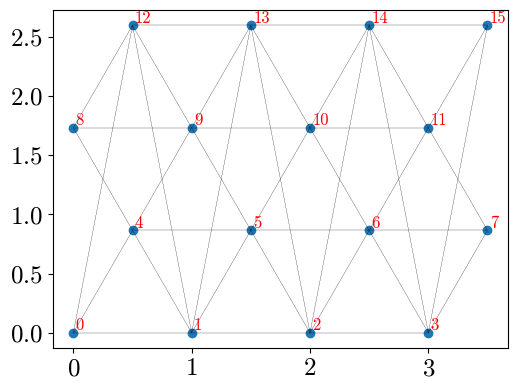

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

adjacency = lattice.create_adjacency_matrix()

x = coords[:, 0]
y = coords[:, 1]

ax.scatter(x, y, marker='o')

shift = 0.02
for idx in range(n_sites):
    x, y = coords[idx]
    ax.annotate(str(idx),  xy=(x+shift, y+shift), fontsize=12, color='r')
    
    # Draw lines to nearest neighbours.
    nn = np.nonzero(adjacency[idx])[0]
    
    for n in nn:
        site_n = coords[n]
        x_n, y_n = site_n
        ax.plot([x, x_n], [y, y_n], "k-", lw=0.1)

ax.set_aspect('equal')

In [12]:
A, B = get_direct_recip_vecs(nrot=3)
print(A)
print(B)

# b1 = 2 * np.pi * np.array([1.0, -1.0 / np.sqrt(3.0)])  # (2π, -2π/√3)
# b2 = (4 * np.pi / np.sqrt(3.0)) * np.array([0.0, 1.0])  # (0, 4π/√3)
# B = np.vstack([b1, b2]).T

symm_kpts = get_symm_kpts(B)
bz_edges, _, _ = get_bz_edges(B)

[[-1.00000000e+00 -5.00000000e-01]
 [ 1.22464680e-16 -8.66025404e-01]]
[[-6.28318531e+00 -8.88505434e-16]
 [ 3.62759873e+00 -7.25519746e+00]]


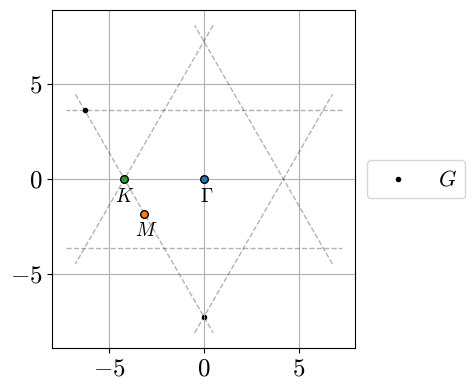

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

for bz_edge in bz_edges:
    ax.plot(bz_edge[:, 0], bz_edge[:, 1], ls='--', lw=1, color='k', alpha=0.3)

ax.scatter(B[0], B[1], marker='.', color='k', label=r'$G$')

G, K, M = symm_kpts
for i, (label, k) in enumerate([(r"$\Gamma$", G), (r"$M$", M), (r"$K$", K)]):
    ax.scatter(*k, marker="o", edgecolor='k', zorder=10, s=30)
    if i == 0: 
        shift_x = -0.2
        shift_y = -1.2

    else:
        shift_x = -0.5
        shift_y = -1.2
        
    ax.text(k[0] + shift_x, k[1] + shift_y, label, color="k", fontsize=14)

# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.grid()
ax.set_aspect('equal')

# Load data

In [14]:
data_path = "./data/"

## DMRG

In [15]:
perm = snake_to_rowmajor_perm(nx, ny)
inv_perm = np.argsort(perm)  # inv_perm[rowmajor] = snake

_spin_corr_dmrg_10 = np.load(data_path + "10/obs_dmrg.npz")["ss"]
_spin_corr_dmrg_16 = np.load(data_path + "16/obs_dmrg.npz")["ss"]

spin_corr_dmrg_10 = _spin_corr_dmrg_10[np.ix_(inv_perm, inv_perm)]
spin_corr_dmrg_16 = _spin_corr_dmrg_16[np.ix_(inv_perm, inv_perm)]

## CPMC

In [16]:
npz_cpmc_10 = np.load(data_path + "10/obs_cpmc.npz")
rdm1_cpmc_10 = npz_cpmc_10["rdm1"]
_density_corr_cpmc_10 = npz_cpmc_10["density_corr"]
_density_corr_cpmc_err_10 = npz_cpmc_10["density_corr_err"]

npz_cpmc_16 = np.load(data_path + "16/obs_cpmc.npz")
rdm1_cpmc_16 = npz_cpmc_16["rdm1"]
_density_corr_cpmc_16 = npz_cpmc_16["density_corr"]
_density_corr_cpmc_err_16 = npz_cpmc_16["density_corr_err"]

density_corr_cpmc_10 = np.block([
        [_density_corr_cpmc_10[0], _density_corr_cpmc_10[1]],
        [_density_corr_cpmc_10[1].T, _density_corr_cpmc_10[2]],
])
density_corr_cpmc_err_10 = np.block([
        [_density_corr_cpmc_err_10[0], _density_corr_cpmc_err_10[1]],
        [_density_corr_cpmc_err_10[1].T, _density_corr_cpmc_err_10[2]],
])

density_corr_cpmc_16 = np.block([
        [_density_corr_cpmc_16[0], _density_corr_cpmc_16[1]],
        [_density_corr_cpmc_16[1].T, _density_corr_cpmc_16[2]],
])

density_corr_cpmc_err_16 = np.block([
        [_density_corr_cpmc_err_16[0], _density_corr_cpmc_err_16[1]],
        [_density_corr_cpmc_err_16[1].T, _density_corr_cpmc_err_16[2]],
])

charge_corr_cpmc_10, spin_corr_cpmc_10, n, sz = get_spin_charge_corr_from_density_corr(density_corr_cpmc_10)
spin_corr_cpmc_10 = 3 * spin_corr_cpmc_10 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>

charge_corr_cpmc_16, spin_corr_cpmc_16, n, sz = get_spin_charge_corr_from_density_corr(density_corr_cpmc_16)
spin_corr_cpmc_16 = 3 * spin_corr_cpmc_16 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>

## Error analysis for CPMC

In [17]:
kdist, labels, ssf_mean_10, ssf_std_10 = bootstrap_ssf_linecut(
    density_corr_cpmc_10, 2 * density_corr_cpmc_err_10, coords, symm_kpts, n_boot=500
)

ssf_mean_10 = 3 * ssf_mean_10 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>
ssf_std_10 = 3 * ssf_std_10 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>

kdist, labels, ssf_mean_16, ssf_std_16 = bootstrap_ssf_linecut(
    density_corr_cpmc_16, 2 * density_corr_cpmc_err_16, coords, symm_kpts, n_boot=500
)
ssf_mean_16 = 3 * ssf_mean_16 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>
ssf_std_16 = 3 * ssf_std_16 # <si^x sj^x> + <si^y sj^y> + <si^z sj^z>

/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22346/1077129288.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22346/1077129288.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_22346/2821230602.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()


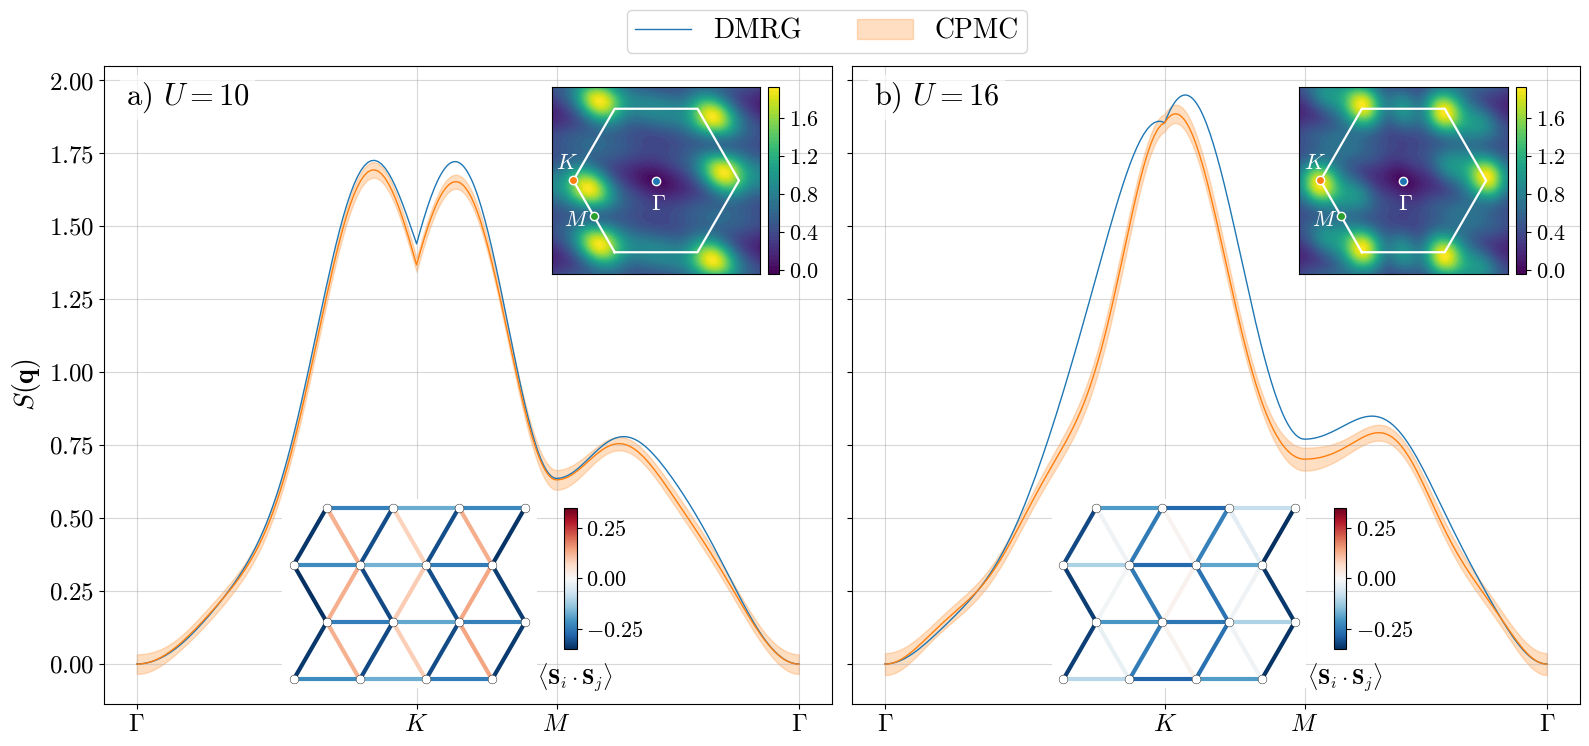

In [18]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, (ax_l, ax_r) = plt.subplots(1, 2, sharey=True, figsize=(16, 7))

make_panel(
    fig,
    ax_l,
    B, 
    symm_kpts,
    spin_corr_dmrg_10,
    spin_corr_cpmc_10,
    coords,
    kdist,
    ssf_mean_10,
    ssf_std_10,
    lattice,
    U_label=10,
    # bz_rect = [0.265, 0.65, 0.29, 0.29],
    bz_rect = [0.28, 0.67, 0.29, 0.29],
    rs_rect = [0.109, 0.09, 0.3, 0.27],
)
ax_l.text(
    0.03,
    0.94,
    r"a) $U = 10$",
    transform=ax_l.transAxes,
    fontsize=22,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

make_panel(
    fig,
    ax_r,
    B, 
    symm_kpts,
    spin_corr_dmrg_16,
    spin_corr_cpmc_16,
    coords,
    kdist,
    ssf_mean_16,
    ssf_std_16,
    lattice,
    U_label=16,
    # bz_rect = [0.735, 0.65, 0.29, 0.29],
    bz_rect = [0.747, 0.67, 0.29, 0.29],
    rs_rect = [0.59, 0.09, 0.3, 0.27],
)
ax_r.set_ylabel("")
ax_r.text(
    0.03,
    0.94,
    r"b) $U = 16$",
    transform=ax_r.transAxes,
    fontsize=22,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

# Get legend entries
handles, labels = ax_l.get_legend_handles_labels()

# Force matplotlib to realize the layout you currently see
fig.canvas.draw()

# Freeze the current layout for THIS figure only.
# This does not change your global rcParams.
fig.set_tight_layout(False)

# Save all current axes positions
old_w, old_h = fig.get_size_inches()
extra_top = 0.55  # inches of extra space for legend
new_h = old_h + extra_top

old_positions = {
    ax: ax.get_position().frozen()
    for ax in fig.axes
}

# Make the canvas taller
fig.set_size_inches(old_w, new_h, forward=True)

# Put every existing axes back at the same physical size/location
# relative to the bottom of the figure.
for ax, pos in old_positions.items():
    ax.set_position([
        pos.x0,
        pos.y0 * old_h / new_h,
        pos.width,
        pos.height * old_h / new_h,
    ])

# Now put the legend in the newly added top space
leg = fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=20,
    borderpad=0.3,
    bbox_to_anchor=(0.52, 1.),
)

# fig.savefig("../figs/ssf.pdf", dpi=400)